# Baseline: target = локальный минимум ±20

Все четыре индикатора оцениваются относительно локального минимума на горизонте 20 свежих публикаций ЦБ.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from fx_signal.baseline import build_baseline_frame

sns.set_theme(style='whitegrid')
HORIZON = 20
CONFIG = Path('../configs/baseline.yaml') if Path.cwd().name == 'notebooks' else Path('configs/baseline.yaml')
frame, metrics = build_baseline_frame(CONFIG, horizon=HORIZON)

## Покрытие и prevalence target

In [2]:
target_col = f'target_local_min_h{HORIZON}'
frame.groupby('currency')[target_col].agg(eligible='count', positives='sum', prevalence='mean')

,eligible,positives,prevalence
currency,,,
AMD,1848,28,0.015152
KGS,1848,29,0.015693
KZT,1848,25,0.013528
TJS,1848,29,0.015693
UZS,1848,28,0.015152


## Hit rate и lift каждого индикатора

In [3]:
metrics.sort_values(['corridor', 'lift'], ascending=[True, False]).reset_index(drop=True)

,horizon,corridor,indicator,eligible_days,signal_count,target_positives,signal_hit_rate,random_hit_rate,lift,signals_per_week
0,20,RUB->AMD,momentum,1779,251,27,0.067729,0.015177,4.462594,0.667807
1,20,RUB->AMD,level,1779,302,27,0.056291,0.015177,3.708977,0.803497
2,20,RUB->AMD,seasonality,1779,356,27,0.016854,0.015177,1.110487,0.947168
3,20,RUB->AMD,reversal,1779,87,27,0.000000,0.015177,0.000000,0.231471
4,20,RUB->KGS,level,1779,361,27,0.058172,0.015177,3.832872,0.960471
5,20,RUB->KGS,momentum,1779,272,27,0.047794,0.015177,3.149101,0.723679
6,20,RUB->KGS,seasonality,1779,382,27,0.015707,0.015177,1.034904,1.016344
7,20,RUB->KGS,reversal,1779,98,27,0.000000,0.015177,0.000000,0.260737
8,20,RUB->KZT,level,1779,379,24,0.042216,0.013491,3.129288,1.008362
9,20,RUB->KZT,momentum,1779,249,24,0.036145,0.013491,2.679217,0.662486


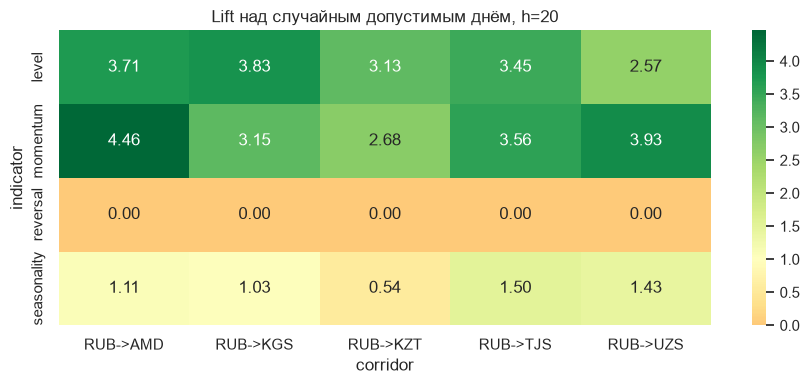

In [4]:
heatmap = metrics.pivot(index='indicator', columns='corridor', values='lift')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap, annot=True, fmt='.2f', center=1.0, cmap='RdYlGn', ax=ax)
ax.set_title(f'Lift над случайным допустимым днём, h={HORIZON}')
fig.tight_layout()
repo_root = CONFIG.resolve().parent.parent
figures_dir = repo_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / f'baseline_lift_h{HORIZON}.png', dpi=160, bbox_inches='tight')

## Интерпретация

lift > 1 означает, что правило чаще случайного допустимого дня совпадает с выбранным local-min target. Reversal срабатывает после минимума, поэтому его низкий lift здесь нельзя считать окончательным выводом о полезности: для него нужна отдельная метрика последующего роста курса.